In [1]:
# --- Force full determinism (must run first, before numpy/umap/numba load) ---
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMBA_NUM_THREADS"] = "1"
os.environ["PYTHONHASHSEED"] = "0"
# If you've already imported numpy/umap in this kernel session before running this cell,
# restart the kernel now and run this cell first -- env vars set after import have no effect.

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('cfpb_with_nlp_features.csv', parse_dates=['Date received', 'Date sent to company'])
embeddings = np.load('narrative_embeddings.npy').astype(np.float32)

print(df.shape, embeddings.shape)
assert len(df) == embeddings.shape[0]  # sanity check they're aligned
df.head(2)

(49850, 24) (49850, 384)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,...,Timely response?,Complaint ID,days_to_route,narrative_word_count,got_relief,sentiment,narrative_for_topics,topic,narrative_for_topics_v2,narrative_for_topics_v3
0,2025-12-29 11:33:13+00:00,Debt collection,I do not know,Attempts to collect debt not owed,Debt is not yours,A collection account is being reported on my c...,No public response,ALLY FINANCIAL INC.,OK,741XX,...,Yes,18337910,9,113,0,-0.4946,A collection account is being reported on my c...,-1,A collection account is being reported on my f...,A collection account is being reported on my f...
1,2025-12-29 14:17:25+00:00,Checking or savings account,Checking account,Opening an account,Account opened without my consent or knowledge,Someone opened a XXXX account connecting it to...,Company has responded to the consumer and the ...,"ARVEST BANK GROUP, INC.",AR,72023,...,Yes,18339989,0,106,0,-0.8225,Someone opened a account connecting it to my c...,-1,Someone opened a account connecting it to my c...,Someone opened a account connecting it to my c...


In [3]:
template_phrases = [
    'falsely reporting on my credit',
    'is a debt collector',
    'against my rights and fair credit act',
    '15 usc 1681',
    'under my rights pursuant to'
]

def is_template(text):
    text_lower = text.lower()
    return int(sum(p in text_lower for p in template_phrases) >= 2)

df['is_template'] = df['Consumer complaint narrative'].apply(is_template)

# Split into 3 groups
groups = {}
for product in df['Product'].unique():
    mask = df['Product'] == product
    groups[product] = {
        'df': df[mask].copy(),
        'embeddings': embeddings[mask.values]   # original 384-dim embeddings, aligned by mask
    }
    print(product, groups[product]['df'].shape)

Debt collection (25083, 25)
Checking or savings account (12552, 25)
Credit card (12215, 25)


In [4]:
from umap import UMAP

for product, g in groups.items():
    print(f"Reducing embeddings for: {product} ({g['embeddings'].shape[0]} rows)")
    reducer = UMAP(n_components=10, n_neighbors=15, min_dist=0.0, metric='cosine', random_state=42, low_memory=True)
    g['embed_reduced'] = reducer.fit_transform(g['embeddings'])
    print(g['embed_reduced'].shape)

Reducing embeddings for: Debt collection (25083 rows)


/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


(25083, 10)
Reducing embeddings for: Checking or savings account (12552 rows)


/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(12552, 10)
Reducing embeddings for: Credit card (12215 rows)


/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(12215, 10)


In [5]:
### Feature Matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder

for product, g in groups.items():
    gdf = g['df']
    
    # Numeric features
    numeric_features = gdf[['sentiment', 'narrative_word_count', 'is_template']].copy()
    scaler = StandardScaler()
    numeric_scaled = scaler.fit_transform(numeric_features)
    
    # Categorical features - cap Issue to top categories within this product group
    top_issues = gdf['Issue'].value_counts().head(10).index
    gdf['Issue_grouped_local'] = gdf['Issue'].where(gdf['Issue'].isin(top_issues), 'Other')
    
    categorical_cols = ['Issue_grouped_local', 'Timely response?']
    categorical_features = gdf[categorical_cols].copy()
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    categorical_encoded = encoder.fit_transform(categorical_features)
    
    # Combine
    final_matrix = np.hstack([g['embed_reduced'], numeric_scaled, categorical_encoded])
    g['final_matrix'] = final_matrix.astype(np.float64)
    
    print(f"{product}: matrix shape {final_matrix.shape}")

Debt collection: matrix shape (25083, 22)
Checking or savings account: matrix shape (12552, 26)
Credit card: matrix shape (12215, 26)


In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for product, g in groups.items():
    matrix = g['final_matrix']
    sample_idx = np.random.RandomState(42).choice(len(matrix), min(5000, len(matrix)), replace=False)
    sample = matrix[sample_idx]
    
    scores = {}
    for k in range(3, 11):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(matrix)
        score = silhouette_score(sample, labels[sample_idx])
        scores[k] = score
    
    g['silhouette_scores'] = scores
    best_k = max(scores, key=scores.get)
    g['best_k'] = best_k
    print(f"\n{product}: best k={best_k} (silhouette={scores[best_k]:.4f})")
    for k, s in scores.items():
        print(f"  k={k}: {s:.4f}")

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/ex


Debt collection: best k=7 (silhouette=0.5674)
  k=3: 0.5243
  k=4: 0.5548
  k=5: 0.5542
  k=6: 0.5672
  k=7: 0.5674
  k=8: 0.1666
  k=9: 0.1710
  k=10: 0.1885


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/ex


Checking or savings account: best k=3 (silhouette=0.4891)
  k=3: 0.4891
  k=4: 0.3395
  k=5: 0.3001
  k=6: 0.3050
  k=7: 0.3217
  k=8: 0.2904
  k=9: 0.2992
  k=10: 0.2893


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/ex


Credit card: best k=9 (silhouette=0.2404)
  k=3: 0.2120
  k=4: 0.2201
  k=5: 0.2384
  k=6: 0.2073
  k=7: 0.2240
  k=8: 0.2303
  k=9: 0.2404
  k=10: 0.2224


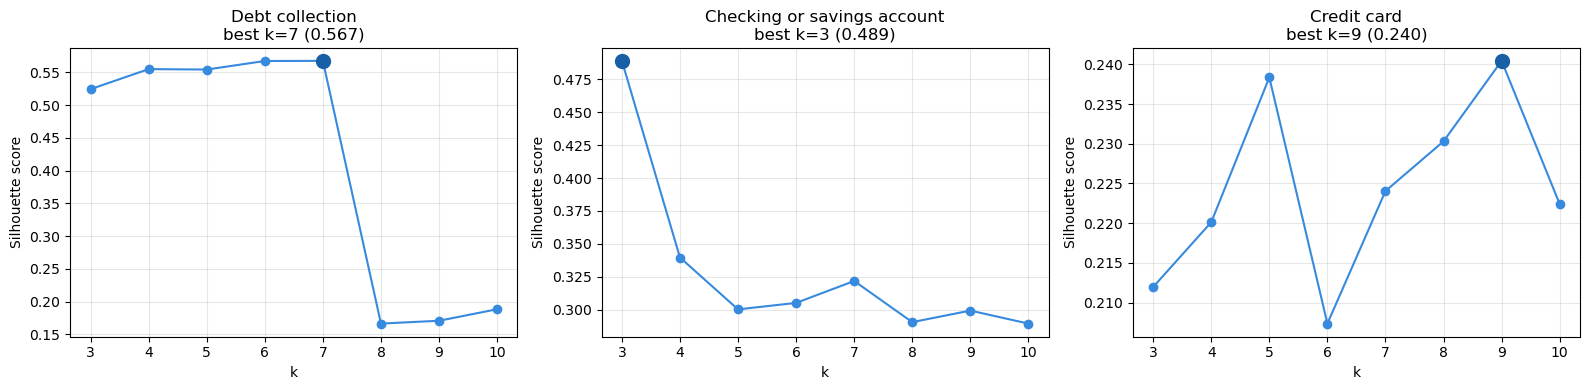

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16,4))

for ax, (product, g) in zip(axes, groups.items()):
    scores = g['silhouette_scores']
    ks = list(scores.keys())
    vals = list(scores.values())
    best_k = max(scores, key=scores.get)
    
    ax.plot(ks, vals, marker='o', color='#378ADD')
    ax.scatter([best_k], [scores[best_k]], color='#185FA5', s=100, zorder=5)
    ax.set_title(f"{product}\nbest k={best_k} ({scores[best_k]:.3f})")
    ax.set_xlabel('k')
    ax.set_ylabel('Silhouette score')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
import hdbscan

credit_matrix = groups['Credit card']['final_matrix']

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=200,    # tune based on result; ~1.5-2% of group size is a reasonable start
    min_samples=10,
    metric='euclidean',
    cluster_selection_method='eom'
)

credit_labels = clusterer.fit_predict(credit_matrix)

n_clusters = len(set(credit_labels)) - (1 if -1 in credit_labels else 0)
n_noise = (credit_labels == -1).sum()
print(f"Clusters found: {n_clusters}")
print(f"Noise points: {n_noise} ({n_noise/len(credit_labels)*100:.1f}%)")

# Silhouette excluding noise points (HDBSCAN convention - silhouette on -1 labels is meaningless)
from sklearn.metrics import silhouette_score
mask = credit_labels != -1
if mask.sum() > 1 and n_clusters > 1:
    sil = silhouette_score(credit_matrix[mask], credit_labels[mask])
    print(f"Silhouette (excluding noise): {sil:.4f}")

Clusters found: 12
Noise points: 2054 (16.8%)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Silhouette (excluding noise): 0.1551


In [9]:
final_ks = {
    'Debt collection': 7,
    'Checking or savings account': 3,
    'Credit card': 4   # simple, interpretable choice given weak/no clear peak
}

for product, g in groups.items():
    k = final_ks[product]
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    g['df']['cluster'] = km.fit_predict(g['final_matrix'])
    g['df']['cluster_label'] = product.split()[0] + '_' + g['df']['cluster'].astype(str)
    print(product, g['df']['cluster_label'].value_counts())

Debt collection cluster_label
Debt_0    19650
Debt_4     1381
Debt_1     1188
Debt_2     1138
Debt_5      840
Debt_6      654
Debt_3      232
Name: count, dtype: int64
Checking or savings account cluster_label
Checking_1    11008
Checking_0     1170
Checking_2      374
Name: count, dtype: int64
Credit card cluster_label
Credit_1    4405
Credit_3    3558
Credit_2    2813
Credit_0    1439
Name: count, dtype: int64


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/ex

In [10]:
df_merged = pd.concat([g['df'] for g in groups.values()], axis=0)
print(df_merged.shape)
print(df_merged['cluster_label'].nunique(), "total segments")

(49850, 28)
14 total segments


                   mean  count
cluster_label                 
Debt_3         0.689655    232
Checking_2     0.331551    374
Debt_1         0.329966   1188
Credit_2       0.298614   2813
Credit_1       0.279455   4405
Credit_3       0.222316   3558
Debt_4         0.221579   1381
Credit_0       0.217512   1439
Debt_5         0.188095    840
Checking_0     0.187179   1170
Checking_1     0.183957  11008
Debt_0         0.173893  19650
Debt_2         0.099297   1138
Debt_6         0.082569    654


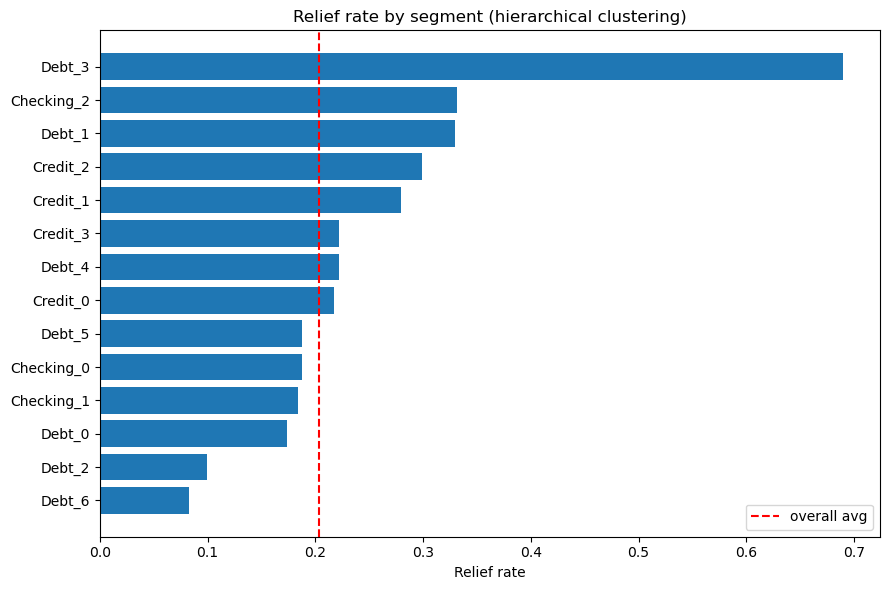

In [11]:
cluster_relief = df_merged.groupby('cluster_label')['got_relief'].agg(['mean', 'count'])
cluster_relief = cluster_relief.sort_values('mean', ascending=False)
print(cluster_relief)

import matplotlib.pyplot as plt
plt.figure(figsize=(9,6))
plt.barh(cluster_relief.index, cluster_relief['mean'])
plt.axvline(df_merged['got_relief'].mean(), color='red', linestyle='--', label='overall avg')
plt.xlabel('Relief rate')
plt.title('Relief rate by segment (hierarchical clustering)')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [12]:
# --- Freeze this clustering result to disk (run ONCE after confirming determinism) ---
# From now on, read cluster labels from this file rather than rerunning UMAP/KMeans,
# so resume/report numbers never drift with library or environment changes.
df_merged.to_parquet('final_clusters.parquet', index=False)
print("Saved frozen clusters:", df_merged.shape)

Saved frozen clusters: (49850, 28)


In [13]:
# --- Robust spread stat: exclude clusters too small to trust the relief rate ---
MIN_N = 500  # below this, relief-rate estimates are too noisy to headline

stable_clusters = cluster_relief[cluster_relief['count'] >= MIN_N]
max_row = stable_clusters['mean'].idxmax()
min_row = stable_clusters['mean'].idxmin()
spread = stable_clusters['mean'].max() / stable_clusters['mean'].min()

print(f"Excluded (n<{MIN_N}): {list(cluster_relief[cluster_relief['count'] < MIN_N].index)}")
print(f"Highest relief: {max_row} = {stable_clusters['mean'].max():.1%} (n={stable_clusters.loc[max_row,'count']})")
print(f"Lowest relief:  {min_row} = {stable_clusters['mean'].min():.1%} (n={stable_clusters.loc[min_row,'count']})")
print(f"Robust spread: {spread:.2f}x")

Excluded (n<500): ['Debt_3', 'Checking_2']
Highest relief: Debt_1 = 33.0% (n=1188)
Lowest relief:  Debt_6 = 8.3% (n=654)
Robust spread: 4.00x


In [14]:
# --- Cluster stability check: bootstrap CI on relief rate per segment ---
import numpy as np
import pandas as pd

def bootstrap_ci(df, group_col, target_col, n_boot=2000, ci=95, random_state=42):
    rng = np.random.RandomState(random_state)
    lo_pct, hi_pct = (100 - ci) / 2, 100 - (100 - ci) / 2
    results = []
    for label, sub in df.groupby(group_col):
        vals = sub[target_col].values
        n = len(vals)
        boot_means = np.array([
            rng.choice(vals, size=n, replace=True).mean() for _ in range(n_boot)
        ])
        lo, hi = np.percentile(boot_means, [lo_pct, hi_pct])
        results.append({'cluster_label': label, 'n': n, 'relief_rate': vals.mean(),
                         'ci_low': lo, 'ci_high': hi, 'ci_width': hi - lo})
    return pd.DataFrame(results).set_index('cluster_label').sort_values('relief_rate', ascending=False)

relief_ci = bootstrap_ci(df_merged, 'cluster_label', 'got_relief', n_boot=2000)
print(relief_ci)

                   n  relief_rate    ci_low   ci_high  ci_width
cluster_label                                                  
Debt_3           232     0.689655  0.629310  0.750000  0.120690
Checking_2       374     0.331551  0.286096  0.379679  0.093583
Debt_1          1188     0.329966  0.303872  0.356061  0.052189
Credit_2        2813     0.298614  0.281550  0.315677  0.034127
Credit_1        4405     0.279455  0.266515  0.293984  0.027469
Credit_3        3558     0.222316  0.209106  0.235540  0.026433
Debt_4          1381     0.221579  0.199855  0.244026  0.044171
Credit_0        1439     0.217512  0.196647  0.239750  0.043103
Debt_5           840     0.188095  0.163095  0.214286  0.051190
Checking_0      1170     0.187179  0.164957  0.210256  0.045299
Checking_1     11008     0.183957  0.176867  0.191045  0.014178
Debt_0         19650     0.173893  0.168448  0.179136  0.010688
Debt_2          1138     0.099297  0.083458  0.116872  0.033414
Debt_6           654     0.082569  0.062

In [15]:
def profile_segment(label):
    sub = df_merged[df_merged['cluster_label'] == label]
    print(f"\n{'='*60}\n{label} (n={len(sub)}, relief={sub['got_relief'].mean():.1%})\n{'='*60}")
    print("Top issues:")
    print(sub['Issue'].value_counts().head(5))
    print(f"\nAvg sentiment: {sub['sentiment'].mean():.2f}")
    print(f"Avg word count: {sub['narrative_word_count'].mean():.0f}")
    print(f"Template rate: {sub['is_template'].mean():.1%}")
    print(f"Timely response rate: {(sub['Timely response?']=='Yes').mean():.1%}")

for label in ['Debt_3', 'Debt_0', 'Debt_6', 'Checking_2', 'Debt_5']:
    profile_segment(label)


Debt_3 (n=232, relief=69.0%)
Top issues:
Issue
Attempts to collect debt not owed    231
Written notification about debt        1
Name: count, dtype: int64

Avg sentiment: 0.77
Avg word count: 68
Template rate: 99.1%
Timely response rate: 100.0%

Debt_0 (n=19650, relief=17.4%)
Top issues:
Issue
Attempts to collect debt not owed                      9503
False statements or representation                     3392
Written notification about debt                        3042
Took or threatened to take negative or legal action    1702
Communication tactics                                  1124
Name: count, dtype: int64

Avg sentiment: -0.25
Avg word count: 200
Template rate: 3.5%
Timely response rate: 96.8%

Debt_6 (n=654, relief=8.3%)
Top issues:
Issue
Attempts to collect debt not owed                                375
Took or threatened to take negative or legal action              246
Written notification about debt                                   30
False statements or representation

In [16]:
import textwrap

for label in ['Debt_0', 'Debt_6']:
    print(f"\n{'='*60}\n{label} — sample narratives\n{'='*60}")
    sample = df_merged[df_merged['cluster_label'] == label].sample(3, random_state=42)
    for _, row in sample.iterrows():
        print(f"\n[sentiment={row['sentiment']:.2f}, relief={row['got_relief']}, template={row['is_template']}]")
        print(textwrap.fill(row['Consumer complaint narrative'][:400], width=90))


Debt_0 — sample narratives

[sentiment=-0.64, relief=0, template=0]
My credit report was negatively affected by Diversified Adjustment Service , Inc., a debt
collector ; for a XXXX account.  I have NEVER had a XXXX account.  After researching, the
debt belongs to someone with the same name as mine. XXXX  email from Diversified
Adjustment Service , Inc shows the name & address. After discussing with the XXXX credit
bureaus, I was directed to report as fraud.

[sentiment=-0.35, relief=1, template=0]
Validation of Debt Request - SPRING OAKS CAPITAL - XXXX XXXX XXXX XXXX XXXX XXXX I am
disputing this account as inaccurate and request full validation, including the original
signed agreement and complete payment history. If you can not verify this debt, you must
delete it from all credit reporting agencies.  Pursuant to the Fair Debt Collection
Practices Act ( FDCPA ) 1006.34, I am entitled to re

[sentiment=-0.97, relief=0, template=0]
I am filing this complaint regarding Starmark Financia

In [17]:
print("Top companies in Debt_3 (low relief):")
print(df_merged[df_merged['cluster_label']=='Debt_3']['Company'].value_counts().head(8))
print()
print("Top companies in Debt_6 (high relief):")
print(df_merged[df_merged['cluster_label']=='Debt_6']['Company'].value_counts().head(8))

Top companies in Debt_3 (low relief):
Company
Portfolio Recovery Associates, LLC       197
CL Holdings LLC                           34
Sentry Recovery and Collections, Inc.      1
Name: count, dtype: int64

Top companies in Debt_6 (high relief):
Company
CL Holdings LLC                           219
ENCORE CAPITAL GROUP INC.                  86
CAINE & WEINER COMPANY, INC.               49
Portfolio Recovery Associates, LLC         19
United Revenue Corporation                 17
Resurgent Capital Services L.P.            17
TRANSUNION INTERMEDIATE HOLDINGS, INC.     15
Experian Information Solutions Inc.        14
Name: count, dtype: int64


In [18]:
# For companies appearing in both clusters, compare their relief rate within each cluster
shared_companies = set(df_merged[df_merged['cluster_label']=='Debt_3']['Company']) & \
                    set(df_merged[df_merged['cluster_label']=='Debt_6']['Company'])

for company in list(shared_companies)[:8]:
    d3_relief = df_merged[(df_merged['cluster_label']=='Debt_3') & (df_merged['Company']==company)]['got_relief'].mean()
    d6_relief = df_merged[(df_merged['cluster_label']=='Debt_6') & (df_merged['Company']==company)]['got_relief'].mean()
    print(f"{company}: Debt_3 relief={d3_relief:.1%}, Debt_6 relief={d6_relief:.1%}")

Portfolio Recovery Associates, LLC: Debt_3 relief=81.2%, Debt_6 relief=31.6%
CL Holdings LLC: Debt_3 relief=0.0%, Debt_6 relief=0.9%


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
import re

def clean_for_topics(text):
    text = re.sub(r'X{2,}', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def get_cluster_keywords(label, top_n=8):
    sub = df_merged[df_merged['cluster_label'] == label]
    texts = sub['Consumer complaint narrative'].apply(clean_for_topics)
    if len(texts) < 5:
        return "Too small"
    tfidf = TfidfVectorizer(max_features=top_n, stop_words='english', ngram_range=(1,2), min_df=3)
    try:
        tfidf.fit(texts)
        return ', '.join(tfidf.get_feature_names_out())
    except ValueError:
        return "Insufficient distinct vocabulary"

summary = cluster_relief.copy()
summary['keywords'] = [get_cluster_keywords(label) for label in summary.index]
print(summary.to_string())

                   mean  count                                                                                      keywords
cluster_label                                                                                                               
Debt_3         0.689655    232  credit, falsely, falsely reporting, portfolio, portfolio rc, rc, reporting, reporting credit
Checking_2     0.331551    374                              00, account, bank, bonus, deposit, offer, promotion, promotional
Debt_1         0.329966   1188                                   15, 15 usc, accounts, accurate, credit, report, rights, usc
Credit_2       0.298614   2813                                  00, account, balance, bank, card, credit, payment, synchrony
Credit_1       0.279455   4405                                    00, account, bank, card, charge, credit, dispute, merchant
Credit_3       0.222316   3558                                00, account, bank, capital, card, credit, credit card, payment
